# 05. 質問設計：167職業のRIASEC空間を先に見る

## 経緯

`01`〜`04`でデータ側（job tag構造の把握、RIASEC欠損補完、認知度ラベル）を固めた。
残る最大の不確実性は「10問で子どもをRIASEC 6次元空間のどこかに配置する」という
質問設計そのもので、ここが成立するかどうかまだ検証していない。しかもここが機能しないと、
RIASEC補完・認知度ラベルの作業が入口を持たないまま無駄になる。不確実性が一番高いところ
から潰す、というここまでと同じ順序で進める。

## 進め方

いきなり質問文を書くのではなく、逆から考える。推薦対象として確定した167職業
（`03`/`04`で確定した、RIASECベクトルと認知度ラベルの両方が揃っている職業）の
RIASECベクトルを先に見て、

1. 6次元がフルに必要なのか、実質もっと低い次元で職業の分布を説明できるのか
   （PCAの寄与率で確認）
2. 職業が実際にどんな塊（クラスタ）を作っているか（人がまばらな領域に配置しても
   意味がないため）

を確認してから、各軸を測る質問を設計する。


In [1]:
import re

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from ipd_loader import load_description, load_numeric

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

desc, desc_labels = load_description()
num, num_labels = load_numeric()
names = num[num.columns[1]]


## 167職業を再構成する（03/04と同じ定義）

In [2]:
riasec_cols = [c for c in num.columns if re.match(r"IPD_04_01_", str(c))]
know_cols = [c for c in num.columns if re.match(r"IPD_04_04_01_", str(c))]
work_cols = [c for c in num.columns if re.match(r"IPD_04_05_", str(c))]

riasec = num[riasec_cols].apply(pd.to_numeric, errors="coerce")
know = num[know_cols].apply(pd.to_numeric, errors="coerce")
work = num[work_cols].apply(pd.to_numeric, errors="coerce")

riasec_observed = ~riasec.isna().all(axis=1)
know_all_missing = know.isna().all(axis=1)
work_all_missing = work.isna().all(axis=1)
no_input = know_all_missing & work_all_missing
predictable = (~riasec_observed) & ~no_input


def scale_domain(domain_df):
    scaler = StandardScaler()
    filled = domain_df.fillna(domain_df.mean())
    scaled = pd.DataFrame(scaler.fit_transform(filled), columns=domain_df.columns, index=domain_df.index)
    return scaled.fillna(0.0)


know_scaled = scale_domain(know)
work_scaled = scale_domain(work)
X_all = pd.concat([know_scaled, work_scaled], axis=1)

from sklearn.linear_model import Ridge

X_train = X_all[riasec_observed]
y_train = riasec[riasec_observed]
riasec_model = Ridge(alpha=1.0).fit(X_train.values, y_train.values)

riasec_full = riasec.copy()
X_pred = X_all[predictable]
riasec_full.loc[predictable, riasec_cols] = riasec_model.predict(X_pred.values)

# 04_awareness_labels.ipynb で確定した179件のラベルを再読み込みし、recommendable=Trueの167件に絞る
awareness = pd.read_csv("../data/processed/awareness_scores.csv", index_col=0)
name_to_numidx = pd.Series(num.index, index=names)

usable_numidx = []
for job_idx, row in awareness[awareness["recommendable"]].iterrows():
    hit = name_to_numidx.get(row["職業名"])
    if hit is None:
        continue
    if isinstance(hit, pd.Series):
        hit = hit.iloc[0]
    usable_numidx.append(hit)

print("推薦対象167件のうち、RIASECベクトルを再構成できた件数:", len(usable_numidx))

riasec_167 = riasec_full.loc[usable_numidx]
job_names_167 = names.loc[usable_numidx]
riasec_167.index = job_names_167.values
riasec_167.columns = [num_labels[c] for c in riasec_167.columns]
riasec_167.head()


推薦対象167件のうち、RIASECベクトルを再構成できた件数: 167


,現実的,研究的,芸術的,社会的,企業的,慣習的
洋菓子製造、パティシエ,3.345,3.000,2.945,3.236,2.836,3.455
ハム・ソーセージ・ベーコン製造,3.304,2.739,2.543,2.826,2.652,3.326
ワイン製造,3.708,3.292,2.958,3.375,3.292,3.375
ビール製造,3.594,3.469,3.031,3.313,3.219,3.219
野菜つけ物製造,3.382,2.818,2.545,2.927,2.691,3.236


## 実質何次元で職業の分布を説明できるか（PCA寄与率）

RIASEC 6因子には相関がある（現実的×研究的は正相関しやすい、等）ため、6次元フルの
解像度が本当に必要かをまず見る。


In [3]:
riasec_scaler = StandardScaler().fit(riasec.loc[riasec_observed, riasec_cols])
riasec_167_z = pd.DataFrame(
    riasec_scaler.transform(riasec_167.values), columns=riasec_167.columns, index=riasec_167.index
)

pca_full = PCA().fit(riasec_167_z.values)
explained = pca_full.explained_variance_ratio_
cumulative = explained.cumsum()

for i, (e, c) in enumerate(zip(explained, cumulative), start=1):
    print(f"PC{i}: 寄与率={e:.1%}  累積={c:.1%}")


PC1: 寄与率=36.8%  累積=36.8%
PC2: 寄与率=23.7%  累積=60.6%
PC3: 寄与率=18.3%  累積=78.9%
PC4: 寄与率=11.1%  累積=90.0%
PC5: 寄与率=5.4%  累積=95.4%
PC6: 寄与率=4.6%  累積=100.0%


/Users/oobasouma/yumetane/api/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 各主成分がRIASECのどの因子に対応するか（負荷量）

主成分が解釈可能かどうかを見る。もし主成分が単一のRIASEC因子にきれいに対応しないなら、
「6因子を独立に測る」という設計自体を見直す材料になる。


In [4]:
loadings = pd.DataFrame(
    pca_full.components_.T, index=riasec_167.columns,
    columns=[f"PC{i+1}" for i in range(len(riasec_cols))],
)
loadings.round(2)


,PC1,PC2,PC3,PC4,PC5,PC6
現実的,0.01,0.69,0.42,0.04,0.52,0.28
研究的,0.53,0.30,0.20,-0.51,-0.24,-0.52
芸術的,0.46,0.35,-0.27,0.69,-0.34,0.05
社会的,0.45,-0.49,0.29,0.34,0.53,-0.28
企業的,0.53,-0.24,0.02,-0.31,-0.08,0.75
慣習的,-0.16,-0.14,0.79,0.22,-0.52,0.09


## クラスタリング：167職業はいくつの塊に分かれるか

In [5]:
results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(riasec_167_z.values)
    sil = silhouette_score(riasec_167_z.values, km.labels_)
    results.append({"k": k, "silhouette": sil, "inertia": km.inertia_})

cluster_eval = pd.DataFrame(results).set_index("k")
cluster_eval.round(3)


,silhouette,inertia
k,,
2,0.216,725.561
3,0.202,615.422
4,0.197,533.034
5,0.186,485.815
6,0.179,445.874
7,0.167,417.190
8,0.168,397.145
9,0.162,375.320
10,0.171,355.560


findfont: Failed to find font weight normal, now using 300.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'IPAexGothic' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'IPAexGothic' not found.


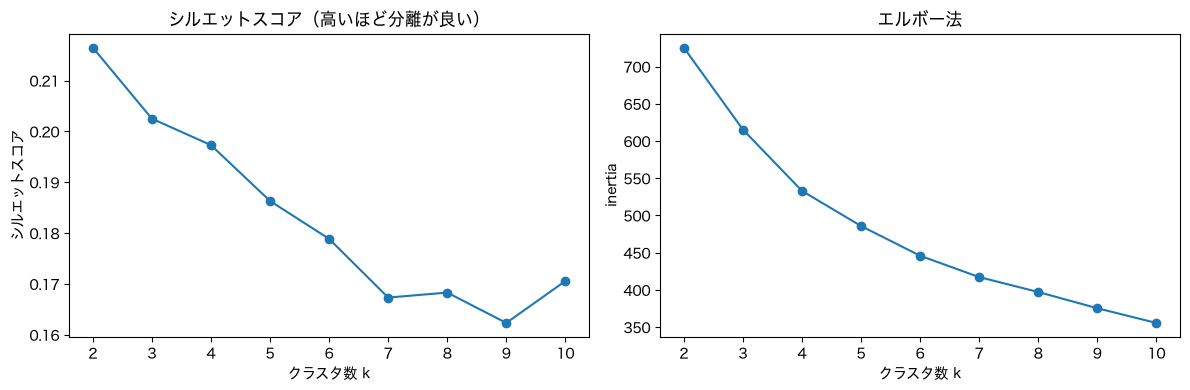

In [6]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = [
    "Hiragino Sans", "Hiragino Kaku Gothic ProN", "Noto Sans CJK JP", "IPAexGothic", "DejaVu Sans",
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cluster_eval.index, cluster_eval["silhouette"], marker="o")
axes[0].set_xlabel("クラスタ数 k")
axes[0].set_ylabel("シルエットスコア")
axes[0].set_title("シルエットスコア（高いほど分離が良い）")

axes[1].plot(cluster_eval.index, cluster_eval["inertia"], marker="o")
axes[1].set_xlabel("クラスタ数 k")
axes[1].set_ylabel("inertia")
axes[1].set_title("エルボー法")
plt.tight_layout()
plt.show()


## 結果の読み方：シルエットスコアの低さが円環構造の裏付けになる

クラスタリングが機能しなかったこと自体が、Hollandの六角形モデル（RIASECは離散的な
タイプではなく連続的な円環構造だとする理論）の裏付けになっている。167職業のデータから
六角形の対立構造（PC1: 慣習的 vs それ以外の積極的関与、PC2: 現実的 vs 社会的）が
そのまま再現されたことは、既存の理論的な設計（子どもを「タイプ分け」するのではなく
連続空間上に配置する）の正しさを裏付ける材料として`docs/design.md`に残す。


## 質問配分：主成分ベースで再構成する

RIASEC 6因子は互いに相関しているため、6因子×独立2問（12問）は質問の冗長を生む
（「研究的」と「芸術的」を測る質問が、実質PC1に沿って同じことを聞いてしまう）。
主成分は定義上直交するため、同じ質問数でより広い空間をカバーできる。寄与率に比例して
10問を配分する。

| 軸 | 寄与率 | 内容（数学的な定義） | 質問数 |
|---|---|---|---|
| PC1 | 36.8% | 研究的・企業的・芸術的・社会的が正／慣習的が負（積極的関与） | 3問 |
| PC2 | 23.7% | 現実的（物）⇔ 社会的（人） | 3問 |
| PC3 | 18.3% | 慣習的・秩序 | 2問 |
| PC4 | 11.1% | 芸術的 ⇔ 研究的 | 2問 |

PC2・PC4は対立軸なので二択（「ひとりで黙々と作るのと、みんなで話しながら進めるの、
どっちが好き？」）で両端を1問で弁別できる。PC3（慣習的）は対立項が無いため、程度を
聞く形（「決まった手順どおりに進めるのは好き？」）になる。

質問文はこの数学的な定義（負荷量）をそのまま日本語にしても子どもには通じない。
各軸の負荷量が高い職業／低い職業を実際に並べて、その職業群に共通する具体的な行動を
人間が言語化する必要がある。


## 各軸の両端の職業リスト

In [7]:
pc_scores = pd.DataFrame(
    pca_full.transform(riasec_167_z.values),
    columns=[f"PC{i+1}" for i in range(len(riasec_cols))],
    index=riasec_167.index,
)

for pc in ["PC1", "PC2", "PC3", "PC4"]:
    print(f"===== {pc} 高い方 上位10 =====")
    print(pc_scores[pc].sort_values(ascending=False).head(10))
    print()
    print(f"===== {pc} 低い方 上位10 =====")
    print(pc_scores[pc].sort_values(ascending=True).head(10))
    print()
    print("-" * 50)


===== PC1 高い方 上位10 =====
学芸員                  3.559856
家庭裁判所調査官             3.344799
法務技官（心理）（矯正心理専門職）    3.272819
ネイリスト                3.139842
音楽教室講師               3.099968
図書編集者                3.008892
雑誌編集者                2.737825
社会学研究者               2.621036
動画制作                 2.482265
メイクアップアーティスト         2.434578
Name: PC1, dtype: float64

===== PC1 低い方 上位10 =====
製品包装作業員        -4.017917
配電盤・制御盤等組立     -3.831637
産業廃棄物収集運搬作業員   -2.743408
光学機器組立         -2.666287
新聞配達員          -2.639734
自動車組立          -2.486106
タイヤ製造          -2.466925
鉄道車掌           -2.288660
ピッキング作業員       -2.231518
化粧品製造          -2.206619
Name: PC1, dtype: float64

--------------------------------------------------
===== PC2 高い方 上位10 =====
録音エンジニア    2.731912
歯科技工士      2.300865
花き栽培者      2.241617
情報工学研究者    1.920417
ピアノ調律師     1.857802
ミシン縫製      1.832857
陶磁器技術者     1.828197
靴製造        1.812411
造園工        1.771147
船舶機関士      1.737620
Name: PC2, dtype: float64

===== PC2 低い方 上位10 =====
キャリアカウンセラー/キャリアコンサ